# End-to-end White Dwarf Spectra Simulations

### Imports

In [2]:
# basic
from copy import deepcopy
from pathlib import Path
from typing import Optional, Literal
import logging
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.io import fits
from astropy.table import Table
from scipy.ndimage import median_filter

# zs_scopesim_tools convenience routines
import zs_scopesim_tools.helpers
from zs_scopesim_tools.helpers import (disable_scopesim_top_level_catch, warning_prevent_sync_alt_ra_dec,
                                       ignore_warnings, set_scopesim_log_level, make_local_output_dir, configure_irdb_path, timed, list_effects, simulate, save_zshooter_readout, subtract_hduls)
# scopesim and scopesim source creation related
import scopesim as sim
import scopesim_templates as sim_tp
from scopesim.source.source import Source
from scopesim.source import source_templates
from zs_scopesim_tools.sources import lamp_flat, transient, kilonova_spectra
from zs_scopesim_tools.plots import PlotScene, plot_readout_overview
from synphot.units import convert_flux, FLAM

# DRP
from zsdrp.ZSHOOTER import ZSHOOTER
import zsdrp.pipe, zsdrp.steps


configure_irdb_path()  # REQUIRED the first time after installation, sets local IRDB directory path in ScopeSim
set_scopesim_log_level("warning")  # set ScopeSim log toggles
disable_scopesim_top_level_catch()
ignore_warnings()
logging.disable(logging.WARNING)

### Setup

In [3]:
OUTDIR = make_local_output_dir(dirname="03_White_dwarf/")

In [4]:
zs_config = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])

##### Helper function to update observing parameters and run simulation in one-shot

Example usage:
```python
hdul, train = update_params_and_observe(
                        object_name = "object_name_identifier", # string name
                        imagetype = "SCIENCE", # one of BIAS, DOMEFLAT, ARCS, SCIENCE
                        source = Source, # scopesim Source object instance
                        exptimes = [300, 300, 300, 100, 100, 100], # list of 6 numbers, one per channel
                        ndit = 2, # Number of exposures to take at above exptime, same for all 6 channels
                        output_dir = "/path/to/output/directory",
                        disable_effects = ["name_of_effect_to_disable", "..."], # see list_effects()
                        disable_backgrounds = ["sky_lines"], # from "sky", "sky_lines", "sky_continuum"
                        airmass = 1.3,
                        seeing = 0.7,
                        brightness = "grey", # options: "bright", "grey", "dark"
                        vis_slit = 0.7, # options: 1.25, 0.70, 0.57, 0.50, 0.42, 0.37, 0.33
                        nir_slit = 0.7, # options: 1.25, 0.70, 0.57, 0.50, 0.42, 0.37, 0.33
                        pixel_scale = None, # uses instrument default
                        pupil_angle = None, # uses instrument default
                        ao_on = False, # AO effect ON/OFF
                        diffuse_emissivity_on = False
)
```
Returns a tuple of:
 - list of size `ndit`, each item of which is a list of 6 fits.HDUList (one per channel), the raw images from scopesim readout
  - The scopesim OpticalTrain object

In [5]:
@timed
def update_params_and_observe(object_name: str,
                              imagetype: str,
                              source: Source,
                              exptimes: Optional[list | float] = None,
                              ndit: int = 1,
                              output_dir: Optional[str | Path]=None,
                              *,
                              disable_effects: Optional[list[str]]=None,
                              disable_backgrounds: Optional[list[Literal["sky", "sky_continuum", "sky_lines"]]]=None,
                              airmass: Optional[float]=None,
                              seeing: Optional[float]=None,
                              brightness: Optional[Literal["bright", "grey", "dark"]]=None,
                              vis_slit: Optional[float]=None,
                              nir_slit: Optional[float]=None,
                              pixel_scale: Optional[float]=None,
                              pupil_angle: Optional[float]=None,
                              ao_on: bool=False,
                              diffuse_emissivity_on: bool=False,
                              params: Optional[dict]=None
                              ) -> tuple[list, sim.optics.OpticalTrain]:
    """
    :param object_name: Name of the Source object
    :param imagetype: IMAGETYPE keyword (BIAS, DOMEFLAT, ARCS, SKY, SCIENCE)
    :param source: Source instance
    :param exptimes: List of exposure times in channel order (blue, green, red, yj, h, k) in seconds, or single value.
                If None, it is set to 0.0.
    :param ndit: number of exposures
    :param output_dir: Directory to save observed data in, FITS files are saved with {object_name}_{CHANNEL}.fits names
                        where CHANNEL is in [BLUE, GREEN, RED, YJ, H, K] (upper case)
    :param disable_effects: List of effect names to disable
    :param disable_backgrounds: List of background names to disable, options are "sky", "sky_continuum", or "sky_lines".
    :param airmass: Airmass
    :param seeing: Seeing (natural)
    :param brightness: Brightness of sky ("bright", "grey", or "dark")
    :param vis_slit: Slit width for Visible channel
    :param nir_slit: Slit width for NIR channel
    :param pixel_scale: Instrument pixel scale
    :param pupil_angle: Instrument pupil angle
    :param ao_on: True for AO correction on, defaults to False
    :param diffuse_emissivity_on: True for diffuse emissivity effect on, defaults to False
    :param params: Dict of any other UserCommands alias keys and values to set

    :return: tuple(HDUList, OpticalTrain)
    """
    if imagetype not in ["BIAS", "DOMEFLAT", "ARCS", "SKY", "SCIENCE"]:
        raise ValueError(f"Imagetype {imagetype} is incorrect! Choose from BIAS, DOMEFLAT, ARCS, SCIENCE.")
    # load ZShooter_v2 irdb model config
    config = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
    # update with passed params
    config["!OBS.airmass"] = airmass if airmass else config["!OBS.airmass"]
    config["!OBS.seeing"] = seeing if seeing else config["!OBS.seeing"]
    config["!OBS.brightness"] = brightness if brightness else config["!OBS.brightness"]
    config["!OBS.pupil_angle"] = pupil_angle if pupil_angle else config["!OBS.pupil_angle"]
    config["!INST.vis_curr_slit"] = vis_slit if vis_slit else config["!INST.vis_curr_slit"]
    config["!INST.nir_curr_slit"] = nir_slit if nir_slit else config["!INST.nir_curr_slit"]
    config["!INST.pixel_scale"] = pixel_scale if pixel_scale else config["!INST.pixel_scale"]
    config["!INST.include_diffuse_emissivity"] = diffuse_emissivity_on
    config["!ATMO.ao_enabled"] = ao_on

    dits = [0.]*6 if exptimes is None else [exptimes]*6 if not isinstance(exptimes, list) else exptimes
    for dit, expkey in zip(dits, ['blue', 'green', 'red', 'yj', 'h', 'k']):
        config[f"!OBS.dit_{expkey}"] = dit
        config[f"!OBS.ndit_{expkey}"] = 1.

    if params is not None and isinstance(params, dict):
        params = {key:val for key, val in params.items() if key in config}
        # USE THIS TO UPDATE THE CONFIG WITH NEW PROPERTIES, IT IS NOT A NORMAL DICT
        config.update_alias(config, params)
    # make sure airmass, ra, dec are in sync if all are provided
    warning_prevent_sync_alt_ra_dec(config)

    # call simulate(), it inits optical train, runs observe() and readout()
    print(f'Simulating {object_name}')
    n_hduls = []
    for i in range(ndit):
        zs, hdul = simulate(config, source=source, disable_effects=disable_effects, disable_backgrounds=disable_backgrounds, hide_progress_bars=True)
        # check desired counts
        print(f'Max counts per channel: {[int(np.max(hdu[1].data)) for hdu in hdul]}')
        # save the simulated readout to fits files
        if output_dir is not None:
            _ = save_zshooter_readout(hdul, output_dir=output_dir, object_name=object_name,
                                          imagetype=imagetype.upper(), ndit=i, cmds=config, train=zs)
            print(f"Saved readout #{i}/{ndit} in {output_dir}")
        n_hduls.append(hdul)

    return n_hduls, zs


### Create Sources

galexj2339_wdmodel_fluxcal


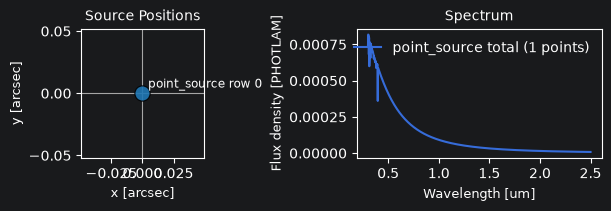

wdzshoo_wdmodel_fluxcal


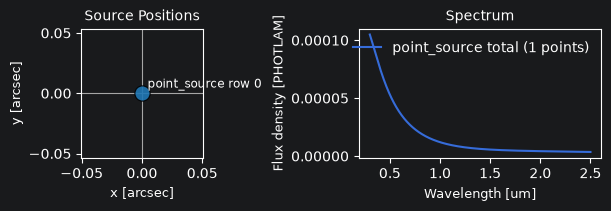

In [6]:
from synphot import SourceSpectrum

spectra_path = Path("source_data/Carl_WD/").resolve()
spectrum_files = sorted(spectra_path.glob("*.dat"))

sources = dict()
for specfile in spectrum_files:
    basename = specfile.stem
    sp = SourceSpectrum.from_file(str(specfile), wave_unit=u.AA, flux_unit=u.mJy)
    sources[basename] = sim_tp.misc.point_source(sed=sp)
    print(basename)
    _ = PlotScene().from_source(sources[basename])
    plt.show()

##### Exposure time guessing

In [23]:
# Flat AB mag source that reaches an SNR=50 in 300s
ref_flux = (16.0 * u.ABmag).to(u.mJy)
ref_exptime = 300 * u.s
ref_snr = 50.0

# from Carl
wave = 3132.7 * u.AA
flux = 1.6269506 * u.mJy
target_snr = 30

# kilonova
ref_photlam = 5e-3 * u.photon / (u.s * u.cm**2 * u.AA)
kn_photlam = 5e-5 * u.photon / (u.s * u.cm**2 * u.AA)

print(ref_photlam / kn_photlam)

ratio = (flux / ref_flux).value
exp_time = ref_exptime * (target_snr / (ref_snr * ratio)) ** 2

print(f"Approximate exposure time: {exp_time:.0f}")


100.0
Approximate exposure time: 85 s


### Simulating cal+science 

Set your observing parameters in cell below.

If you change any instrument related parameters for a science object simulation (like vis_slit, nir_slit, ao_on or diffuse_emissivity_on)
 - **<font color='red'>Make sure to simulate a complementary set of cals with the same parameters!</font>**
 - **<font color='red'>Make sure you CHANGE the output_dir so that your data doesn't get overwritten!</font>**

#### Configuration 1: galexj2339_wdmodel_fluxcal spectrum at high res

In [7]:
airmass = 1.3
seeing = 0.7
brightness = "grey"
vis_slit = 0.3
nir_slit = 0.3
ao_on = False
diffuse_emissivity_on = False
params = {"!SIM.spectral.spectral_bin_width": 0.000005}
# creating a sub-directory in OUTDIR for this run config, naming it based on config params
output_dir = OUTDIR / f"slit_{vis_slit}"
output_dir.mkdir(parents=True, exist_ok=True)

overwrite_cals = True  # set True to redo cals
plot = False  # Set True for plotting

args = {'airmass':airmass, 'seeing':seeing, 'brightness':brightness, 'vis_slit':vis_slit, 'nir_slit':nir_slit,
        'ao_on': ao_on, 'diffuse_emissivity_on': diffuse_emissivity_on, 'params': params}

In [85]:
# for cals
disable_effects_cals = ["atmo_transmission", "continuum_emission", "airglow_and_interline_continuum",
                        "seeing_psf", "adc_residuals"]
if overwrite_cals or len(sorted(output_dir.glob("*bias*")))!=6:
    # bias
    bias_hdul, _ = update_params_and_observe(object_name="bias", imagetype="BIAS", source=None, exptimes=0,
                                             output_dir=output_dir, disable_effects=disable_effects_cals, **args)
    # arcs
    LAMP = lamp_flat()
    arcs_hdul, _ = update_params_and_observe(object_name="arcs", imagetype="ARCS", source=LAMP,
                                             exptimes=[40, 40, 3, 3, 20, 10], output_dir=output_dir,
                                             disable_effects=disable_effects_cals, **args)
    # domeflat
    DOMEFLAT = sim_tp.calibration.flat_field(temperature=3000*u.K, amplitude=8*u.ABmag, filter_curve='V', extend=60)
    domeflat_hdul, _ = update_params_and_observe(object_name="domeflat", imagetype="DOMEFLAT", source=DOMEFLAT,
                                                 exptimes=[120, 10, 3, 3, 3, 3], output_dir=output_dir,
                                                 disable_effects=disable_effects_cals, **args)
    # standard star
    STANDARD = sim_tp.misc.point_source(sed=source_templates.ab_spectrum(mag=16))
    std_hdul, _ = update_params_and_observe(object_name="standard", imagetype="SCIENCE", source=STANDARD,
                                            exptimes=100, disable_backgrounds=["sky"], output_dir=output_dir, **args)
    if plot:
        _, _ = plot_readout_overview(bias_hdul,
                                        titles=[f"bias {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])
        _, _ = PlotScene().from_source(LAMP)
        _, _ = plot_readout_overview(arcs_hdul,
                                        titles=[f"arcs {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])
        _, _ = plot_readout_overview(domeflat_hdul,
                                        titles=[f"domeflat {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])
        _, _ = plot_readout_overview(std_hdul,
                                        titles=[f"standard {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])

Simulating bias
Max counts per channel: [1040, 1040, 1040, 2, 2, 2]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/03_White_dwarf/slit_0.33
update_params_and_observe(bias): 38.5 s
Simulating arcs
Max counts per channel: [21559, 31567, 33160, 30842, 33541, 37458]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/03_White_dwarf/slit_0.33
update_params_and_observe(arcs): 41.5 s
Simulating domeflat
Max counts per channel: [20580, 21561, 25469, 34463, 38675, 36365]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/03_White_dwarf/slit_0.33
update_params_and_observe(domeflat): 43.6 s
Simulating standard
Max counts per channel: [1103, 1122, 1142, 111, 119, 461]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/03_White_dwarf/slit_0.33
update_params_and_observe(standard): 74.1 s


In [87]:
from zs_scopesim_tools.helpers import subtract_hduls

for exptime in [2700, 3600]:
    #sky
    sky_hduls, _ = update_params_and_observe(object_name=f"sky_{exptime}", imagetype="SKY", source=None, exptimes=exptime, output_dir=output_dir, **args)

    objname = list(sources.keys())[0]
    hduls, _ = update_params_and_observe(object_name=f"{objname}_{exptime}", imagetype="SCIENCE", source=sources[objname], exptimes=exptime, ndit=2, output_dir=output_dir, **args)

    for i, hdul in enumerate(hduls):
        sub_hdul = subtract_hduls(hdul, sky_hduls[0])
        # save the sky-subtracted readout to fits files
        _ = save_zshooter_readout(sub_hdul, output_dir=output_dir, object_name=f"{objname}_{exptime}_SUB",
                                  imagetype="SCIENCE", ndit=i, cmds=None, train=None, extra_headers={"SUBTRACTED": True})


Simulating sky_2700
Max counts per channel: [1083, 8736, 33254, 211985, 1121055, 399699]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/03_White_dwarf/slit_0.33
update_params_and_observe(sky_2700): 67.5 s
Simulating galexj2339_wdmodel_fluxcal_2700
Max counts per channel: [2261, 9507, 33503, 211632, 1120529, 399032]
Saved readout #0/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/03_White_dwarf/slit_0.33
Max counts per channel: [2255, 9545, 33526, 212026, 1120091, 398961]
Saved readout #1/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/03_White_dwarf/slit_0.33
update_params_and_observe(galexj2339_wdmodel_fluxcal_2700): 151.5 s
Simulating sky_3600
Max counts per channel: [1091, 11393, 44004, 282327, 1493270, 532970]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/03_White_dwarf/slit_0.33
update_params_and_observe(sky_3600): 55.2 s
Simulating galexj2339_wdmodel_fluxcal_3600
Max counts per channel: [2665, 12347, 445

Reduce

In [8]:
REDUCED_DIR = output_dir / f"reduced"
# make sure the reduced dir exists
REDUCED_DIR.mkdir(exist_ok=True)

In [9]:
zspy = ZSHOOTER()
files = {}
for chan in zspy.config.channels:
    stepnames = ['bias','flat','wavecal_master','science']
    file_groups = zspy.sort_files(str(output_dir), target='', night='', channel=chan, steps=stepnames)
    _, fls = file_groups[0]
    files[chan] = {name: fls[name] for name in stepnames}
# files[chan]

results = zsdrp.pipe.run_reduction(files, channels=None, output_dir=REDUCED_DIR, disable_steps=['mask'], print_params=False, disable_all_plots=True, reuse_cals=True)

reference = source_templates.ab_spectrum(mag=16)
reference_wave = reference.waveset
reference_flux = convert_flux(reference_wave, reference(reference_wave), "FLAM")

final_spectra = zsdrp.pipe.run_flux_calibration_and_stitch(results, reference_wave=reference_wave, reference_flux=reference_flux, plot=False, output_dir=REDUCED_DIR)

del results
del final_spectra

100%|██████████| 234/234 [00:00<00:00, 1594.70it/s]


Running reduction for channel BLUE...
Running reduction for channel GREEN...
Running reduction for channel RED...
Running reduction for channel YJ...
Running reduction for channel H...
Running reduction for channel K...


galexj2339_wdmodel_fluxcal_1200_SUB: mean SNR = 50.30, median SNR = 50.92
Median SNR at 3100 +- 5 $\AA$:  19.058055495808343
Median SNR at 3125 -+ 5 $\AA$:  23.63612829770845
galexj2339_wdmodel_fluxcal_1800_SUB: mean SNR = 60.55, median SNR = 61.17
Median SNR at 3100 +- 5 $\AA$:  22.425775127195145
Median SNR at 3125 -+ 5 $\AA$:  27.945868702614835
galexj2339_wdmodel_fluxcal_2700_SUB: mean SNR = 72.40, median SNR = 73.13
Median SNR at 3100 +- 5 $\AA$:  26.204824781945526
Median SNR at 3125 -+ 5 $\AA$:  32.33245064338957
galexj2339_wdmodel_fluxcal_3600_SUB: mean SNR = 81.70, median SNR = 82.36
Median SNR at 3100 +- 5 $\AA$:  29.890893680643313
Median SNR at 3125 -+ 5 $\AA$:  38.023487663916235


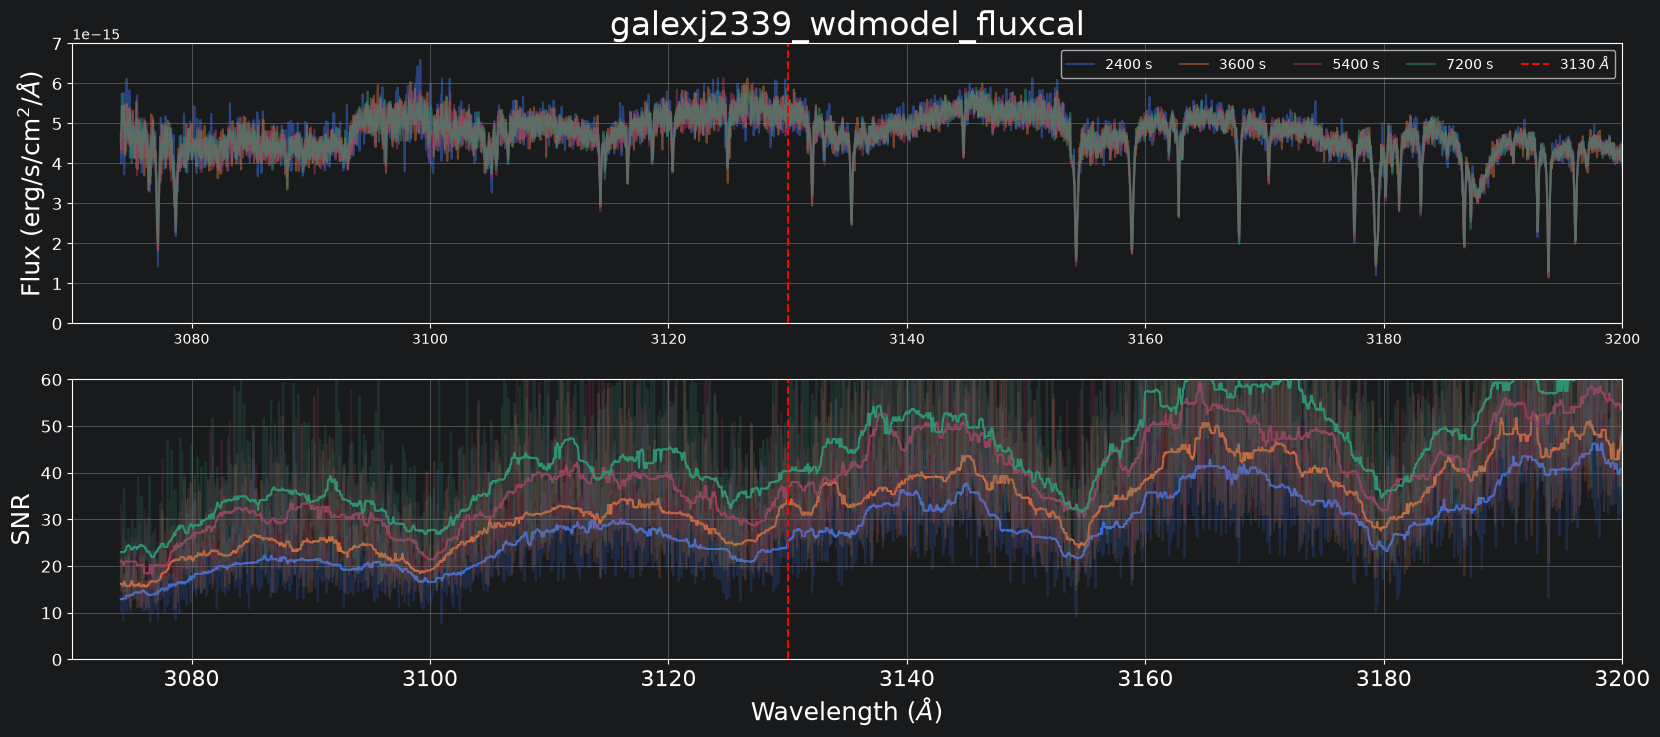

In [10]:
fig, ax = plt.subplots(2,1, figsize=(20,8))
ax[0].grid(True)
ax[1].grid(True)
ax[0].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='x', labelsize=16)
ax[0].set_ylabel('Flux (erg/s/cm$^2/\AA$)', fontsize=18)
ax[1].set_ylabel('SNR', fontsize=18)
ax[1].set_xlabel('Wavelength ($\AA$)', fontsize=18)

stitched = sorted(REDUCED_DIR.glob('*stitched.txt'))

obj = list(sources.keys())[0]
for i,exptime in enumerate([1200, 1800, 2700, 3600]):
    objname = f"{obj}_{exptime}_SUB"
    flname = sorted(REDUCED_DIR.glob(f'*{objname.upper()}*stitched.txt'))[0]
    with open(flname, 'r', encoding='utf-8') as f:
        tbl = pd.read_csv(f, sep='\t', comment='# ', engine='python')
        wave = tbl['wavelength']
        spec = tbl['flux']
        sig = tbl['eflux']
        snr = spec/sig
        good = np.isfinite(snr)
        print(f"{objname}: mean SNR = {np.mean(snr[good]):.2f}, "
              f"median SNR = {np.median(snr[good]):.2f}")

        sel1 = (wave > 3100-5) & (wave < 3100+5)
        print(r'Median SNR at 3100 +- 5 $\AA$: ', np.nanmedian(snr[sel1]))
        sel2 = (wave > 3125-5) & (wave < 3125+5)
        print(r'Median SNR at 3125 -+ 5 $\AA$: ', np.nanmedian(snr[sel2]))
        ax[0].plot(wave, spec, alpha=0.5, color=f"C{i}", label=str(2*exptime)+' s')
        # ax[0].plot(wave, median_filter(spec, 51), label=str(2*exptime), color=f"C{i}")
        ax[1].plot(wave, snr, alpha=0.2, color=f"C{i}")
        ax[1].plot(wave, median_filter(snr , 51), label=str(2*exptime), color=f"C{i}")

ax[0].set_title(obj, fontsize=24)
ax[0].axvline(3130, color='red', ls='--', label='3130 $\AA$')
ax[1].axvline(3130, color='red', ls='--')
ax[0].set_xlim(3070, 3200)
ax[1].set_xlim(3070, 3200)
ax[0].set_ylim(0, 0.7e-14)
ax[1].set_ylim(0, 60)
ax[0].legend(ncol=5)
plt.show()

#### Configuration 2: wdzshoo_wdmodel_fluxcal spectrum at low res

In [79]:
airmass = 1.3
seeing = 0.7
brightness = "grey"
vis_slit = 1.25
nir_slit = 1.25
ao_on = False
diffuse_emissivity_on = False
params = {"!SIM.spectral.spectral_bin_width": 0.00001}
# creating a sub-directory in OUTDIR for this run config, naming it based on config params
output_dir = OUTDIR / f"slit_{vis_slit}"
output_dir.mkdir(parents=True, exist_ok=True)

overwrite_cals = True  # set True to redo cals
plot = False  # Set True for plotting

args = {'airmass':airmass, 'seeing':seeing, 'brightness':brightness, 'vis_slit':vis_slit, 'nir_slit':nir_slit,
        'ao_on': ao_on, 'diffuse_emissivity_on': diffuse_emissivity_on, 'params': params}

In [38]:
# for cals
disable_effects_cals = ["atmo_transmission", "continuum_emission", "airglow_and_interline_continuum",
                        "seeing_psf", "adc_residuals"]
if overwrite_cals or len(sorted(output_dir.glob("*bias*")))!=6:
    # bias
    bias_hdul, _ = update_params_and_observe(object_name="bias", imagetype="BIAS", source=None, exptimes=0,
                                             output_dir=output_dir, disable_effects=disable_effects_cals, **args)
    # arcs
    LAMP = lamp_flat()
    arcs_hdul, _ = update_params_and_observe(object_name="arcs", imagetype="ARCS", source=LAMP,
                                             exptimes=[40, 40, 3, 3, 20, 10], output_dir=output_dir,
                                             disable_effects=disable_effects_cals, **args)
    # domeflat
    DOMEFLAT = sim_tp.calibration.flat_field(temperature=3000*u.K, amplitude=8*u.ABmag, filter_curve='V', extend=60)
    domeflat_hdul, _ = update_params_and_observe(object_name="domeflat", imagetype="DOMEFLAT", source=DOMEFLAT,
                                                 exptimes=[120, 10, 3, 3, 3, 3], output_dir=output_dir,
                                                 disable_effects=disable_effects_cals, **args)
    # standard star
    STANDARD = sim_tp.misc.point_source(sed=source_templates.ab_spectrum(mag=16))
    std_hdul, _ = update_params_and_observe(object_name="standard", imagetype="SCIENCE", source=STANDARD,
                                            exptimes=100, disable_backgrounds="sky", output_dir=output_dir, **args)
    if plot:
        _, _ = plot_readout_overview(bias_hdul,
                                        titles=[f"bias {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])
        _, _ = PlotScene().from_source(LAMP)
        _, _ = plot_readout_overview(arcs_hdul,
                                        titles=[f"arcs {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])
        _, _ = plot_readout_overview(domeflat_hdul,
                                        titles=[f"domeflat {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])
        _, _ = plot_readout_overview(std_hdul,
                                        titles=[f"standard {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])

Simulating bias
Max counts per channel: [1040, 1040, 1040, 2, 2, 2]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/03_White_dwarf/slit_1.25
update_params_and_observe(bias): 28.7 s
Simulating arcs
Max counts per channel: [28686, 34616, 31960, 32228, 33479, 36057]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/03_White_dwarf/slit_1.25
update_params_and_observe(arcs): 30.0 s
Simulating domeflat
Max counts per channel: [56004, 58869, 69644, 97295, 108986, 102925]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/03_White_dwarf/slit_1.25
update_params_and_observe(domeflat): 29.3 s
Simulating standard
Max counts per channel: [1177, 1226, 1271, 251, 259, 1490]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/03_White_dwarf/slit_1.25
update_params_and_observe(standard): 47.2 s


In [80]:
from zs_scopesim_tools.helpers import subtract_hduls

for exptime in [4500]:
    #sky
    sky_hduls, _ = update_params_and_observe(object_name=f"sky_{exptime}", imagetype="SKY", source=None, exptimes=exptime, output_dir=output_dir, **args)

    objname = "wdzshoo_wdmodel_fluxcal"
    hduls, _ = update_params_and_observe(object_name=f"{objname}_{exptime}", imagetype="SCIENCE", source=sources[objname], exptimes=exptime, ndit=2, output_dir=output_dir, **args)

    for i, hdul in enumerate(hduls):
        sub_hdul = subtract_hduls(hdul, sky_hduls[0])
        # save the sky-subtracted readout to fits files
        _ = save_zshooter_readout(sub_hdul, output_dir=output_dir, object_name=f"{objname}_{exptime}_SUB",
                                  imagetype="SCIENCE", ndit=i, cmds=None, train=None, extra_headers={"SUBTRACTED": True})


Simulating sky_4500
Max counts per channel: [1207, 13802, 55624, 386006, 2086246, 1103409]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/03_White_dwarf/slit_1.25
update_params_and_observe(sky_4500): 68.2 s
Simulating wdzshoo_wdmodel_fluxcal_4500
Max counts per channel: [1894, 14168, 55663, 385240, 2084095, 1102153]
Saved readout #0/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/03_White_dwarf/slit_1.25
Max counts per channel: [1883, 14058, 55728, 384904, 2084988, 1104161]
Saved readout #1/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/03_White_dwarf/slit_1.25
update_params_and_observe(wdzshoo_wdmodel_fluxcal_4500): 138.6 s


Reduce

In [11]:
REDUCED_DIR = output_dir / f"reduced"
# make sure the reduced dir exists
REDUCED_DIR.mkdir(exist_ok=True)

In [103]:
zspy = ZSHOOTER()
files = {}
for chan in zspy.config.channels:
    stepnames = ['bias','flat','wavecal_master','science']
    file_groups = zspy.sort_files(str(output_dir), target='', night='', channel=chan, steps=stepnames)
    _, fls = file_groups[0]
    files[chan] = {name: fls[name] for name in stepnames}

results = zsdrp.pipe.run_reduction(files, channels=None, output_dir=REDUCED_DIR, disable_steps=['mask'], print_params=False, disable_all_plots=True, reuse_cals=True)

reference = source_templates.ab_spectrum(mag=16)
reference_wave = reference.waveset
reference_flux = convert_flux(reference_wave, reference(reference_wave), "FLAM")

final_spectra = zsdrp.pipe.run_flux_calibration_and_stitch(results, reference_wave=reference_wave, reference_flux=reference_flux, plot=False, output_dir=REDUCED_DIR)
del results, final_spectra


wdzshoo_wdmodel_fluxcal_1800_SUB: mean SNR = 24.75, median SNR = 24.76
Median SNR at 23000~24000 $\AA$:  2.0489727931936073
Median SNR at 23000~24000 $\AA$:  6.155432931041745
wdzshoo_wdmodel_fluxcal_2700_SUB: mean SNR = 30.24, median SNR = 30.24
Median SNR at 23000~24000 $\AA$:  2.514194894383004
Median SNR at 23000~24000 $\AA$:  7.895642586402069
wdzshoo_wdmodel_fluxcal_3600_SUB: mean SNR = 34.85, median SNR = 34.92
Median SNR at 23000~24000 $\AA$:  2.980458456524453
Median SNR at 23000~24000 $\AA$:  9.125781673955515
wdzshoo_wdmodel_fluxcal_4500_SUB: mean SNR = 38.93, median SNR = 39.08
Median SNR at 23000~24000 $\AA$:  3.283982587899113
Median SNR at 23000~24000 $\AA$:  10.003388106446486


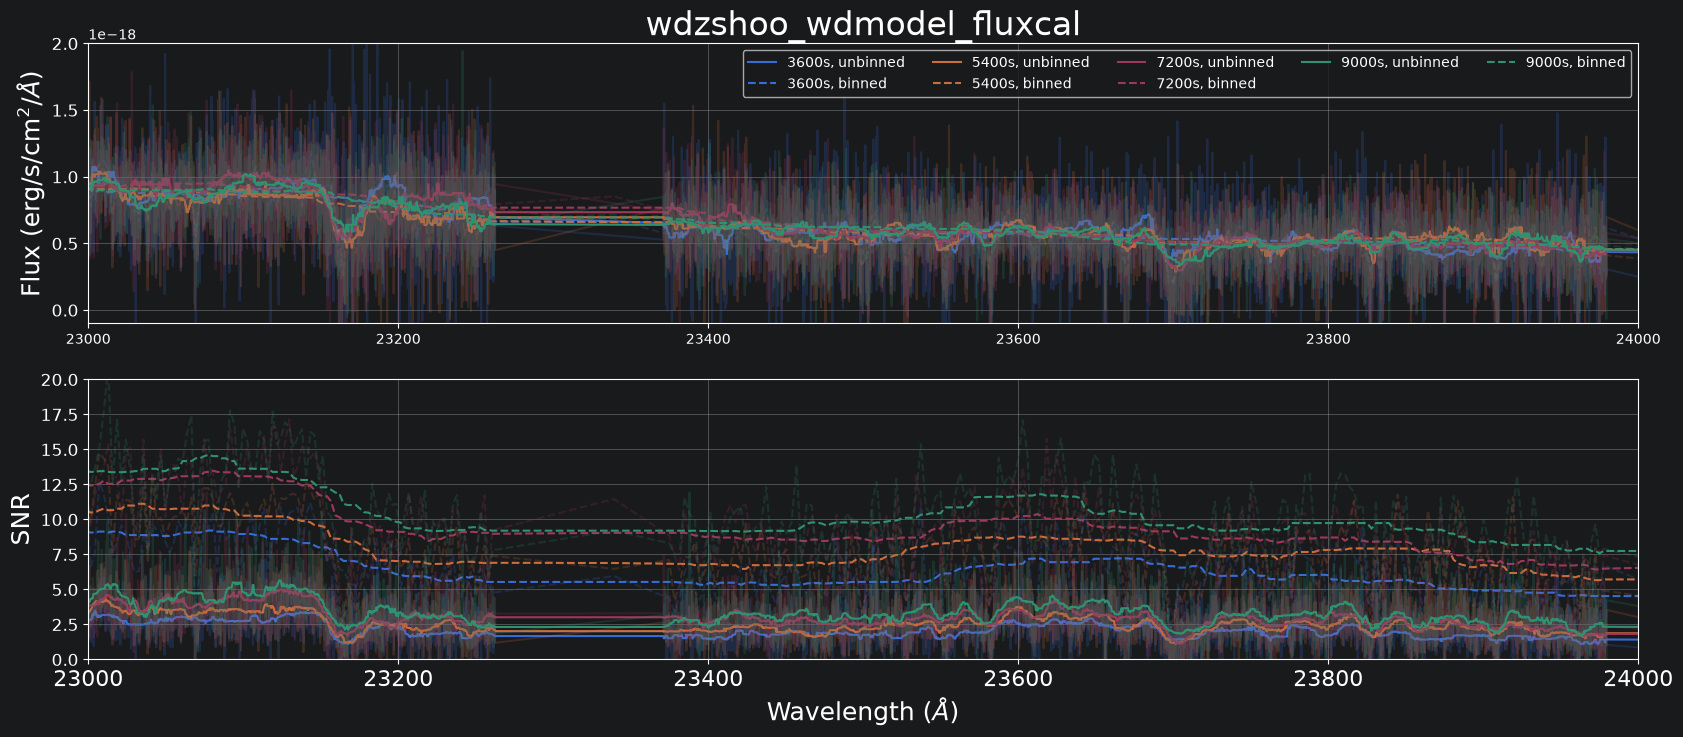

In [105]:
fig, ax = plt.subplots(2,1, figsize=(20,8))
ax[0].grid(True)
ax[1].grid(True)
ax[0].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='x', labelsize=16)
ax[0].set_ylabel('Flux (erg/s/cm$^2/\AA$)', fontsize=18)
ax[1].set_ylabel('SNR', fontsize=18)
ax[1].set_xlabel('Wavelength ($\AA$)', fontsize=18)

stitched = sorted(REDUCED_DIR.glob('*stitched.txt'))

obj = list(sources.keys())[1]
for i,exptime in enumerate([1800, 2700, 3600, 4500]):
    objname = f"{obj}_{exptime}_SUB"
    flname = sorted(REDUCED_DIR.glob(f'*{objname.upper()}*stitched.txt'))[0]
    with open(flname, 'r', encoding='utf-8') as f:
        tbl = pd.read_csv(f, sep='\t', comment='# ', engine='python')
        wave = tbl['wavelength']
        spec = tbl['flux']
        sig = tbl['eflux']
        snr = spec/sig
        good = np.isfinite(snr)
        print(f"{objname}: mean SNR = {np.mean(snr[good]):.2f}, "
              f"median SNR = {np.median(snr[good]):.2f}")

        sel1 = (wave > 23000) & (wave < 24000)
        print(r'Median SNR at 23000~24000 $\AA$: ', np.nanmedian(snr[sel1]))
        ax[0].plot(wave, spec, alpha=0.2, color=f"C{i}")
        ax[0].plot(wave, median_filter(spec, 51), label=str(2*exptime)+'s, unbinned', color=f"C{i}")
        ax[1].plot(wave, snr, alpha=0.2, color=f"C{i}")
        ax[1].plot(wave, median_filter(snr , 51), color=f"C{i}")

        tbl['bins'] = np.arange(len(tbl)) // 10
        binned = []
        for _, group in tbl.groupby(by='bins'):
            binned.append([np.mean(group['wavelength']),
                           np.mean(group['flux']),
                           np.sqrt(np.sum(group['eflux']**2))/len(group)])
        bintbl = pd.DataFrame(binned, columns=['wavelength', 'flux', 'eflux'])
        bintbl.to_csv(str(flname).replace('stitched', 'stitched_binned_10'), sep='\t', index=False)
        binsnr = bintbl['flux']/bintbl['eflux']
        sel1 = (bintbl['wavelength'] > 23000) & (bintbl['wavelength'] < 24000)
        print(r'Median SNR at 23000~24000 $\AA$: ', np.nanmedian(binsnr[sel1]))
        ax[0].plot(bintbl['wavelength'], bintbl['flux'], alpha=0.2, color=f"C{i}", ls='--')
        ax[0].plot(bintbl['wavelength'], median_filter(bintbl['flux'], 51), label=str(2*exptime)+'s, binned', color=f"C{i}", ls='--')
        ax[1].plot(bintbl['wavelength'], binsnr, alpha=0.2, color=f"C{i}", ls='--')
        ax[1].plot(bintbl['wavelength'], median_filter(binsnr , 51), label=objname, color=f"C{i}", ls='--')

ax[0].set_title(obj, fontsize=24)
ax[0].set_xlim(23000, 24000)
ax[1].set_xlim(23000, 24000)
ax[0].set_ylim(-0.01e-17, 0.2e-17)
ax[1].set_ylim(0, 20)
ax[0].legend(ncol=5)
plt.show()